# ML Pipeline for 5Ghz Device Prediction Positioning Model

This notebook contains the machine learning pipeline used to train V4 of the device positioning model from the labelled dataset in `ml_dataset.parquet`.

<br>

---

<br>

## Regression Problem

The machine learning task is formulated as a supervised multi-output regression problem:

$$
f(\mathbf{x}_i) \to \mathbf{y}_i =
\begin{bmatrix}
x_i \\
y_i
\end{bmatrix}
$$

where:

- $\mathbf{x}_i$ is the input feature vector for the $i$-th sample
- $\mathbf{y}_i$ is the ground-truth 2D target position
- $f(\cdot)$ is the learned regression function

Equivalently, the model learns:

$$
\hat{\mathbf{y}}_i = f(\mathbf{x}_i)
$$

with prediction error measured by the Euclidean localisation error:

$$
e_i = \sqrt{(\hat{x}_i - x_i)^2 + (\hat{y}_i - y_i)^2}
$$

The training objective is to learn a function $f$ that minimises prediction error over all training samples.

This notebook follows four core principles:
1. Use one row per `scenario_id` + `target_id`.
2. Split by unseen `scenario_id` groups rather than by random rows.
3. Compare simple baselines before more complex fusion models.
4. Drop leakage columns that would not exist at inference time.

<br>

---

<br>

## Data Split Strategy

To evaluate generalisation to unseen environments, the dataset **(100 network environments)** is split by unique `scenario_id` groups. This prevents the model from seeing the same environment in both training and evaluation, which would otherwise inflate performance.

The grouped split used in this notebook is:

- **Training set (70%)**  = 70 environments
- **Validation set (20%)**  = 20 environments
- **Testing set (10%)**  = 10 environments

<br>

#### Note:
> Because the split is group-based, the exact environment counts must be rounded to whole numbers.
> One important constraint is that no `scenario_id` appears in more than one split.


In [1]:
%pip install -q pandas pyarrow scikit-learn matplotlib seaborn

In [2]:
import time
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit, ParameterSampler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 13  # Keeping it the same as the environment seed for reproducibility

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def localisation_error_m(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.sum((y_true - y_pred) ** 2, axis=1))


def metric_row(split_name, model_name, y_true, y_pred):
    errors = localisation_error_m(y_true, y_pred)
    # Exclude NaN/Inf errors so that methods with failed estimates still report valid statistics
    finite_errors = errors[np.isfinite(errors)]
    if len(finite_errors) == 0:
        return {
            "split": split_name,
            "model": model_name,
            "sample_count": 0,
            "mean_error_m": float("nan"),
            "median_error_m": float("nan"),
            "rmse_m": float("nan"),
            "p90_error_m": float("nan"),
        }
    return {
        "split": split_name,
        "model": model_name,
        "sample_count": int(len(finite_errors)),
        "mean_error_m": float(finite_errors.mean()),
        "median_error_m": float(np.median(finite_errors)),
        "rmse_m": float(np.sqrt(np.mean(finite_errors ** 2))),
        "p90_error_m": float(np.quantile(finite_errors, 0.90)),
    }


def describe_split(name, frame):
    print(
        f"{name}: rows={len(frame):,}, scenarios={frame['scenario_id'].nunique()}"
    )


## 1. Load `ml_dataset.parquet`

In [3]:
DATA_PATH = Path("/ML Pipeline/ml_dataset.parquet").resolve()

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Update DATA_PATH so it points to a local ml_dataset.parquet file."
    )

DATA_DIR = DATA_PATH.parent
dataset_df = pd.read_parquet(DATA_PATH).copy()

print(f"Loaded: {DATA_PATH}")
print(f"Rows: {len(dataset_df):,}")
print(f"Unique scenarios: {dataset_df['scenario_id'].nunique()}")
display(dataset_df.head())


Loaded: /ML Pipeline/ml_dataset.parquet
Rows: 654,871
Unique scenarios: 100


,scenario_id,target_id,target_x,target_y,area,env_type,width,height,x_domain_min,x_domain_max,y_range_min,y_range_max,antenna_count,human_count,floor_plan_room_count,floor_plan_patio_count,floor_plan_element_count,antenna_layout_count,antenna_x_mean,antenna_y_mean,antenna_x_min,antenna_x_max,antenna_y_min,antenna_y_max,antenna_coverage_radius_mean_m,antenna_coverage_radius_min_m,antenna_coverage_radius_max_m,antenna_x_std,antenna_y_std,rssi_measurement_count,rssi_signal_mean_dbm,rssi_signal_min_dbm,rssi_signal_max_dbm,rssi_signal_std_dbm,tdoa_measurement_count,tdoa_observed_mean_ns,tdoa_observed_min_ns,tdoa_observed_max_ns,tdoa_observed_std_ns,doa_measurement_count,doa_observed_bearing_sin_mean,doa_observed_bearing_cos_mean,doa_observed_doa_sin_mean,doa_observed_doa_cos_mean
0,scenario_0001,0,-175.234457,-303.093029,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,-427.752710,-752.790307,-174.056410,182.312451,14,1038.975804,343.519124,1800.349473,468.824051,15,-0.763459,-0.462595,-0.763459,-0.462595
1,scenario_0001,1,-170.298275,-303.093029,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,-429.895284,-780.524718,-159.268821,190.750655,14,1042.163876,339.795480,1803.966870,470.824975,15,-0.785318,-0.411440,-0.785318,-0.411440
2,scenario_0001,2,-165.362093,-303.093029,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,-441.171674,-764.818835,-168.322370,184.128985,14,1044.300092,334.684405,1806.697223,472.894041,15,-0.762210,-0.502821,-0.762210,-0.502821
3,scenario_0001,3,-160.425911,-303.093029,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,-448.458166,-796.269888,-164.106154,190.117570,14,1046.409585,329.236888,1809.143405,474.977080,15,-0.803608,-0.427545,-0.803608,-0.427545
4,scenario_0001,4,-155.489729,-303.093029,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,-471.360853,-865.758716,-157.140176,208.520910,14,1047.818113,323.188976,1811.057069,477.101039,15,-0.737397,-0.519173,-0.737397,-0.519173


In [4]:
baseline_error_cols = [
    column for column in ["rssi_error_m", "tdoa_error_m", "doa_error_m"]
    if column in dataset_df.columns
]

if baseline_error_cols:
    baseline_summary_df = (
        dataset_df[baseline_error_cols]
        .describe()
        .T[["mean", "50%", "max"]]
        .rename(columns={"50%": "median"})
    )
    display(baseline_summary_df)

scenario_count = dataset_df["scenario_id"].nunique()
if scenario_count < 10:
    warnings.warn(
        "This dataset has fewer than 10 scenarios. The notebook will run, but should probably use the full 100-scenario dataset for the real experiment.",
        stacklevel=2,
    )


## 2. Keep only inference-safe features

The model should not see any column that directly encodes the target, uses ground-truth geometry, or depends on hidden simulator parameters.


In [5]:
IDENTIFIER_COLUMNS = ["scenario_id", "target_id"]
TARGET_COLUMNS = ["target_x", "target_y"]

# IMPORTANT: Estimation columns must NOT be used as ML features to avoid data leakage.
# These columns (rssi_est_x/y, tdoa_est_x/y, doa_est_x/y) are the OUTPUT of conventional positioning methods, not INPUT environmental or measurement data.
# Using them as features would make the ML model learn to improve those estimates, not learn the fundamental relationship between environment + raw telemetry + ground truth.
# They are included in model_df solely for baseline comparison and plotting after training.

MEASUREMENT_FEATURE_COLUMNS = [
    "rssi_measurement_count",
    "rssi_signal_mean_dbm",
    "rssi_signal_min_dbm",
    "rssi_signal_max_dbm",
    "rssi_signal_std_dbm",
    "tdoa_measurement_count",
    "tdoa_observed_mean_ns",
    "tdoa_observed_min_ns",
    "tdoa_observed_max_ns",
    "tdoa_observed_std_ns",
    "doa_measurement_count",
    "doa_observed_bearing_sin_mean",
    "doa_observed_bearing_cos_mean",
    "doa_observed_doa_sin_mean",
    "doa_observed_doa_cos_mean",
]

METADATA_FEATURE_COLUMNS = [
    "env_type",
    "area",
    "width",
    "height",
    "x_domain_min",
    "x_domain_max",
    "y_range_min",
    "y_range_max",
    "antenna_count",
    "human_count",
    "floor_plan_room_count",
    "floor_plan_patio_count",
    "floor_plan_element_count",
    "antenna_layout_count",
    "antenna_x_mean",
    "antenna_y_mean",
    "antenna_x_min",
    "antenna_x_max",
    "antenna_y_min",
    "antenna_y_max",
    "antenna_coverage_radius_mean_m",
    "antenna_coverage_radius_min_m",
    "antenna_coverage_radius_max_m",
    "antenna_x_std",
    "antenna_y_std",
]

ALLOWED_FEATURE_COLUMNS = [
    *MEASUREMENT_FEATURE_COLUMNS,
    *METADATA_FEATURE_COLUMNS,
]

available_feature_columns = [
    column for column in ALLOWED_FEATURE_COLUMNS if column in dataset_df.columns
]
missing_feature_columns = [
    column for column in ALLOWED_FEATURE_COLUMNS if column not in dataset_df.columns
]

# Identify estimation columns — these are NOT ML features (no leakage), but are included for baseline comparison and plotting only.
BASELINE_EST_COLUMNS = [
    col for col in dataset_df.columns
    if col.startswith(("rssi_est", "tdoa_est", "doa_est"))
]
if BASELINE_EST_COLUMNS:
    print(
        f"Note: Estimation columns retained for baseline comparison only "
        f"(excluded from ML features): {BASELINE_EST_COLUMNS}"
    )

model_df = dataset_df[
    IDENTIFIER_COLUMNS + TARGET_COLUMNS + available_feature_columns + BASELINE_EST_COLUMNS
].copy()

assert "scenario_id" not in available_feature_columns
assert "target_x" not in available_feature_columns
assert "target_y" not in available_feature_columns
assert not any(col.startswith(("rssi_est", "tdoa_est", "doa_est")) for col in available_feature_columns)

print(f"Features kept: {len(available_feature_columns)}")
print(f"Missing from dataset: {len(missing_feature_columns)}")
print("\nKept feature columns:")
print(available_feature_columns)

if missing_feature_columns:
    print("\nAllowed-but-missing columns for this dataset version:")
    print(missing_feature_columns)

display(model_df.head())


Features kept: 40
Missing from dataset: 0

Kept feature columns:
['rssi_measurement_count', 'rssi_signal_mean_dbm', 'rssi_signal_min_dbm', 'rssi_signal_max_dbm', 'rssi_signal_std_dbm', 'tdoa_measurement_count', 'tdoa_observed_mean_ns', 'tdoa_observed_min_ns', 'tdoa_observed_max_ns', 'tdoa_observed_std_ns', 'doa_measurement_count', 'doa_observed_bearing_sin_mean', 'doa_observed_bearing_cos_mean', 'doa_observed_doa_sin_mean', 'doa_observed_doa_cos_mean', 'env_type', 'area', 'width', 'height', 'x_domain_min', 'x_domain_max', 'y_range_min', 'y_range_max', 'antenna_count', 'human_count', 'floor_plan_room_count', 'floor_plan_patio_count', 'floor_plan_element_count', 'antenna_layout_count', 'antenna_x_mean', 'antenna_y_mean', 'antenna_x_min', 'antenna_x_max', 'antenna_y_min', 'antenna_y_max', 'antenna_coverage_radius_mean_m', 'antenna_coverage_radius_min_m', 'antenna_coverage_radius_max_m', 'antenna_x_std', 'antenna_y_std']


,scenario_id,target_id,target_x,target_y,rssi_measurement_count,rssi_signal_mean_dbm,rssi_signal_min_dbm,rssi_signal_max_dbm,rssi_signal_std_dbm,tdoa_measurement_count,tdoa_observed_mean_ns,tdoa_observed_min_ns,tdoa_observed_max_ns,tdoa_observed_std_ns,doa_measurement_count,doa_observed_bearing_sin_mean,doa_observed_bearing_cos_mean,doa_observed_doa_sin_mean,doa_observed_doa_cos_mean,env_type,area,width,height,x_domain_min,x_domain_max,y_range_min,y_range_max,antenna_count,human_count,floor_plan_room_count,floor_plan_patio_count,floor_plan_element_count,antenna_layout_count,antenna_x_mean,antenna_y_mean,antenna_x_min,antenna_x_max,antenna_y_min,antenna_y_max,antenna_coverage_radius_mean_m,antenna_coverage_radius_min_m,antenna_coverage_radius_max_m,antenna_x_std,antenna_y_std
0,scenario_0001,0,-175.234457,-303.093029,15,-427.752710,-752.790307,-174.056410,182.312451,14,1038.975804,343.519124,1800.349473,468.824051,15,-0.763459,-0.462595,-0.763459,-0.462595,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
1,scenario_0001,1,-170.298275,-303.093029,15,-429.895284,-780.524718,-159.268821,190.750655,14,1042.163876,339.795480,1803.966870,470.824975,15,-0.785318,-0.411440,-0.785318,-0.411440,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
2,scenario_0001,2,-165.362093,-303.093029,15,-441.171674,-764.818835,-168.322370,184.128985,14,1044.300092,334.684405,1806.697223,472.894041,15,-0.762210,-0.502821,-0.762210,-0.502821,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
3,scenario_0001,3,-160.425911,-303.093029,15,-448.458166,-796.269888,-164.106154,190.117570,14,1046.409585,329.236888,1809.143405,474.977080,15,-0.803608,-0.427545,-0.803608,-0.427545,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
4,scenario_0001,4,-155.489729,-303.093029,15,-471.360853,-865.758716,-157.140176,208.520910,14,1047.818113,323.188976,1811.057069,477.101039,15,-0.737397,-0.519173,-0.737397,-0.519173,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803


## 3. Split by unseen scenarios

Never random-split rows for the main experiment. The training set, validation set, and test set must use different `scenario_id` groups. This notebook uses a grouped 70:20:10 split.


In [6]:
TRAIN_SIZE = 0.70
VALID_SIZE = 0.20
TEST_SIZE = 0.10


def grouped_train_valid_test_split(
    frame,
    group_col="scenario_id",
    train_size=TRAIN_SIZE,
    valid_size=VALID_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
):
    total = train_size + valid_size + test_size
    if not np.isclose(total, 1.0):
        raise ValueError("train_size, valid_size, and test_size must sum to 1.0")

    unique_groups = frame[group_col].nunique()
    if unique_groups < 3:
        raise ValueError("Need at least 3 unique scenarios for train/valid/test splitting.")

    outer_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )
    train_valid_idx, test_idx = next(
        outer_splitter.split(frame, groups=frame[group_col])
    )
    train_valid_df = frame.iloc[train_valid_idx].copy()
    test_df = frame.iloc[test_idx].copy()

    valid_fraction_of_remaining = valid_size / (train_size + valid_size)
    inner_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=valid_fraction_of_remaining,
        random_state=random_state + 1,
    )
    train_idx, valid_idx = next(
        inner_splitter.split(train_valid_df, groups=train_valid_df[group_col])
    )
    train_df = train_valid_df.iloc[train_idx].copy()
    valid_df = train_valid_df.iloc[valid_idx].copy()
    return train_df, valid_df, test_df


train_df, valid_df, test_df = grouped_train_valid_test_split(model_df)

describe_split("train", train_df)
describe_split("valid", valid_df)
describe_split("test", test_df)

print("\nScenario overlap checks")
print("train/valid overlap:", set(train_df["scenario_id"]) & set(valid_df["scenario_id"]))
print("train/test overlap:", set(train_df["scenario_id"]) & set(test_df["scenario_id"]))
print("valid/test overlap:", set(valid_df["scenario_id"]) & set(test_df["scenario_id"]))


train: rows=444,864, scenarios=69
valid: rows=155,597, scenarios=21
test: rows=54,410, scenarios=10

Scenario overlap checks
train/valid overlap: set()
train/test overlap: set()
valid/test overlap: set()


## 4. Direct baselines and simple linear fusion

Start with the classical estimates already produced by the simulator, then fit a small linear fusion model using only the three estimate coordinate pairs.


In [7]:
BASELINE_COORD_COLUMNS = [
    "rssi_est_x",
    "rssi_est_y",
    "tdoa_est_x",
    "tdoa_est_y",
    "doa_est_x",
    "doa_est_y",
]

BASELINE_ESTIMATE_MAP = {
    "RSSI": ("rssi_est_x", "rssi_est_y"),
    "TDOA": ("tdoa_est_x", "tdoa_est_y"),
    "DOA": ("doa_est_x", "doa_est_y"),
}

# Only keep baseline columns that actually exist in the dataset
available_baseline_columns = [c for c in BASELINE_COORD_COLUMNS if c in valid_df.columns]
available_baseline_map = {
    label: cols
    for label, cols in BASELINE_ESTIMATE_MAP.items()
    if all(c in valid_df.columns for c in cols)
}


def comparison_subset(frame):
    finite_mask = np.isfinite(frame[TARGET_COLUMNS].to_numpy(dtype=float)).all(axis=1)
    if available_baseline_columns:
        finite_mask &= np.isfinite(frame[available_baseline_columns].to_numpy(dtype=float)).all(axis=1)
    return frame.loc[finite_mask].copy()


valid_eval_df = comparison_subset(valid_df)
test_eval_df = comparison_subset(test_df)

print(f"Validation comparison rows: {len(valid_eval_df):,}")
print(f"Test comparison rows: {len(test_eval_df):,}")

baseline_results = []
prediction_store = {}

# Initialise result frames so they are always defined for the summary concat in the next cell
baseline_results_df = pd.DataFrame()
linear_results_df = pd.DataFrame()
linear_test_pred = None

if not available_baseline_map:
    print("No baseline estimate columns found in dataset — skipping direct baseline comparison.")
else:
    for split_name, split_df in [("valid", valid_eval_df), ("test", test_eval_df)]:
        y_split = split_df[TARGET_COLUMNS].to_numpy(dtype=float)
        for label, columns in available_baseline_map.items():
            preds = split_df.loc[:, list(columns)].to_numpy(dtype=float)
            baseline_results.append(metric_row(split_name, label, y_split, preds))
            if split_name == "test":
                prediction_store[label] = preds

    baseline_results_df = pd.DataFrame(baseline_results).sort_values(["split", "mean_error_m"])
    display(baseline_results_df)

# Linear fusion: combine the three baseline estimates using a learned linear model.
# This is a baseline comparison model — it uses the estimate columns intentionally and is NOT part of the primary ML training pipeline.
FUSION_BASELINE_COLUMNS = available_baseline_columns

y_valid = valid_eval_df[TARGET_COLUMNS].to_numpy(dtype=float)
y_test = test_eval_df[TARGET_COLUMNS].to_numpy(dtype=float)

if FUSION_BASELINE_COLUMNS:
    linear_fusion_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )

    X_train_linear = train_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)
    y_train_linear = train_df[TARGET_COLUMNS].to_numpy(dtype=float)
    X_valid_linear = valid_eval_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)
    X_test_linear = test_eval_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)

    linear_fusion_pipeline.fit(X_train_linear, y_train_linear)
    linear_valid_pred = linear_fusion_pipeline.predict(X_valid_linear)
    linear_test_pred = linear_fusion_pipeline.predict(X_test_linear)

    linear_results_df = pd.DataFrame(
        [
            metric_row("valid", "Linear fusion", y_valid, linear_valid_pred),
            metric_row("test", "Linear fusion", y_test, linear_test_pred),
        ]
    )
    prediction_store["Linear fusion"] = linear_test_pred
    display(linear_results_df)
else:
    print("No baseline estimate columns available — skipping linear fusion baseline.")


Validation comparison rows: 155,597
Test comparison rows: 54,410
No baseline estimate columns found in dataset — skipping direct baseline comparison.
No baseline estimate columns available — skipping linear fusion baseline.


## 5. Full tabular fusion models with Colab tree tuning

The primary model is tree-based. This section tunes only the tree model, keeps the MLP as a secondary comparison, and never uses the held-out test split for hyperparameter selection.


In [8]:
numeric_feature_columns = [
    column
    for column in available_feature_columns
    if pd.api.types.is_numeric_dtype(train_df[column])
]
categorical_feature_columns = [
    column for column in available_feature_columns if column not in numeric_feature_columns
]

DEFAULT_TREE_PARAMS = {
    "learning_rate": 0.05,
    "max_depth": 6,
    "max_iter": 300,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 32,
    "l2_regularization": 0.0,
    "max_bins": 255,
    "random_state": RANDOM_STATE,
}
TREE_PARAM_COLUMNS = [
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "max_depth",
    "min_samples_leaf",
    "l2_regularization",
    "max_bins",
]
TREE_TUNING_SEARCH_SPACE = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_iter": [200, 300, 500, 800, 1000],
    "max_leaf_nodes": [15, 31, 63, 127],
    "max_depth": [None, 4, 6, 8, 10],
    "min_samples_leaf": [16, 32, 64, 128],
    "l2_regularization": [0.0, 0.001, 0.01, 0.1, 1.0],
    "max_bins": [64, 128, 255],
}

RUN_TREE_TUNING = True
TREE_TUNING_N_TRIALS = 150  # total screening trials, including default trial 0
TREE_TUNING_TOP_K = 10
TREE_TUNING_ROWS_PER_SCENARIO = 1000
TREE_TUNING_RESULTS_PATH = DATA_DIR / "tree_tuning_results.csv"


def make_preprocessor():
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    categorical_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_feature_columns),
            ("cat", Pipeline(steps=categorical_steps), categorical_feature_columns),
        ],
        remainder="drop",
    )


def normalise_tree_params(model_params=None):
    params = DEFAULT_TREE_PARAMS.copy()
    if model_params:
        params.update(model_params)
    params["random_state"] = RANDOM_STATE
    return params


def make_tree_pipeline(model_params=None):
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                MultiOutputRegressor(
                    HistGradientBoostingRegressor(
                        **normalise_tree_params(model_params)
                    )
                ),
            ),
        ]
    )


def make_mlp_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=(128, 64),
                    activation="relu",
                    alpha=1e-4,
                    batch_size=1024,
                    max_iter=200,
                    early_stopping=True,
                    n_iter_no_change=15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def scenario_balanced_sample(frame, rows_per_scenario, random_state=RANDOM_STATE):
    if rows_per_scenario is None:
        return frame.copy()

    sampled_parts = []
    for _, group in frame.groupby("scenario_id", sort=True):
        n = min(len(group), rows_per_scenario)
        sampled_parts.append(group.sample(n=n, random_state=random_state))

    sampled_df = pd.concat(sampled_parts, axis=0)
    return sampled_df.sample(frac=1.0, random_state=random_state).copy()


def build_tree_trial_params(n_trials=TREE_TUNING_N_TRIALS):
    if n_trials < 1:
        raise ValueError("TREE_TUNING_N_TRIALS must be at least 1.")

    trials = [normalise_tree_params()]
    sampler = ParameterSampler(
        TREE_TUNING_SEARCH_SPACE,
        n_iter=int(min(n_trials + 20, np.prod([len(v) for v in TREE_TUNING_SEARCH_SPACE.values()]))),
        random_state=RANDOM_STATE,
    )
    seen = {tuple((key, trials[0].get(key)) for key in TREE_PARAM_COLUMNS)}
    for sampled_params in sampler:
        params = normalise_tree_params(sampled_params)
        key = tuple((name, params.get(name)) for name in TREE_PARAM_COLUMNS)
        if key in seen:
            continue
        trials.append(params)
        seen.add(key)
        if len(trials) >= n_trials:
            break
    return trials


def tree_params_to_row(params):
    row = {}
    for key in TREE_PARAM_COLUMNS:
        value = params.get(key)
        row[f"param_{key}"] = "None" if value is None else value
    return row


def coerce_tree_param(key, value):
    if key == "max_depth" and (pd.isna(value) or value == "None"):
        return None
    if pd.isna(value):
        return None
    if key in {"max_iter", "max_leaf_nodes", "min_samples_leaf", "max_bins"}:
        return int(float(value))
    return float(value)


def tree_params_from_row(row):
    params = {
        key: coerce_tree_param(key, row[f"param_{key}"])
        for key in TREE_PARAM_COLUMNS
    }
    return normalise_tree_params(params)


def load_tree_tuning_results():
    if TREE_TUNING_RESULTS_PATH.exists():
        return pd.read_csv(TREE_TUNING_RESULTS_PATH)
    return pd.DataFrame()


def append_tree_tuning_result(row):
    result_df = pd.DataFrame([row])
    result_df.to_csv(
        TREE_TUNING_RESULTS_PATH,
        mode="a",
        header=not TREE_TUNING_RESULTS_PATH.exists(),
        index=False,
    )


def evaluate_tree_params(stage, trial_id, params, X_fit, y_fit, X_valid, y_valid, train_row_count):
    started = time.time()
    row = {
        "stage": stage,
        "trial_id": int(trial_id),
        "is_default": bool(trial_id == 0),
        "train_row_count": int(train_row_count),
        "valid_row_count": int(len(X_valid)),
        **tree_params_to_row(params),
    }

    try:
        candidate_pipeline = make_tree_pipeline(params)
        candidate_pipeline.fit(X_fit, y_fit)
        valid_pred = candidate_pipeline.predict(X_valid)
        metrics = metric_row("valid", f"Tree tuning {stage}", y_valid, valid_pred)
        row.update(metrics)
        row["status"] = "ok"
        row["error_message"] = ""
    except Exception as exc:
        row.update(
            {
                "split": "valid",
                "model": f"Tree tuning {stage}",
                "sample_count": 0,
                "mean_error_m": float("nan"),
                "median_error_m": float("nan"),
                "rmse_m": float("nan"),
                "p90_error_m": float("nan"),
                "status": "failed",
                "error_message": str(exc)[:500],
            }
        )
    row["fit_seconds"] = round(time.time() - started, 3)
    append_tree_tuning_result(row)
    return row


def run_tree_tuning_stage(stage, trial_items, X_fit, y_fit, X_valid, y_valid):
    existing_df = load_tree_tuning_results()
    completed = set()
    if not existing_df.empty:
        completed = set(
            zip(existing_df["stage"].astype(str), existing_df["trial_id"].astype(int))
        )

    new_rows = []
    for index, (trial_id, params) in enumerate(trial_items, start=1):
        if (stage, int(trial_id)) in completed:
            print(f"Skipping completed {stage} trial {trial_id} ({index}/{len(trial_items)})")
            continue

        print(f"Running {stage} trial {trial_id} ({index}/{len(trial_items)})")
        row = evaluate_tree_params(
            stage,
            trial_id,
            params,
            X_fit,
            y_fit,
            X_valid,
            y_valid,
            train_row_count=len(X_fit),
        )
        new_rows.append(row)
        if row["status"] == "ok":
            print(
                f"  mean={row['mean_error_m']:.4f} m, "
                f"median={row['median_error_m']:.4f} m, "
                f"p90={row['p90_error_m']:.4f} m"
            )
        else:
            print(f"  failed: {row['error_message']}")

    return load_tree_tuning_results()


def successful_stage_results(stage):
    results_df = load_tree_tuning_results()
    if results_df.empty:
        return results_df
    stage_df = results_df[
        (results_df["stage"] == stage) & (results_df["status"] == "ok")
    ].copy()
    if stage_df.empty:
        return stage_df
    return stage_df.sort_values("mean_error_m").reset_index(drop=True)


X_train_full = train_df[available_feature_columns].copy()
X_valid_full = valid_eval_df[available_feature_columns].copy()
X_test_full = test_eval_df[available_feature_columns].copy()
y_train = train_df[TARGET_COLUMNS].to_numpy(dtype=float)

if RUN_TREE_TUNING:
    if TREE_TUNING_RESULTS_PATH.exists():
        print(f"Resuming tree tuning from: {TREE_TUNING_RESULTS_PATH}")
    else:
        print(f"Writing tree tuning results to: {TREE_TUNING_RESULTS_PATH}")

    tuning_train_df = scenario_balanced_sample(
        train_df,
        rows_per_scenario=TREE_TUNING_ROWS_PER_SCENARIO,
        random_state=RANDOM_STATE,
    )
    X_train_screen = tuning_train_df[available_feature_columns].copy()
    y_train_screen = tuning_train_df[TARGET_COLUMNS].to_numpy(dtype=float)

    print(
        "Tree tuning screening subset: "
        f"{len(tuning_train_df):,} rows across "
        f"{tuning_train_df['scenario_id'].nunique()} train scenarios"
    )
    print(
        "Validation set used for model selection: "
        f"{len(valid_eval_df):,} rows across "
        f"{valid_eval_df['scenario_id'].nunique()} validation scenarios"
    )

    all_trial_params = build_tree_trial_params(TREE_TUNING_N_TRIALS)
    screening_trials = list(enumerate(all_trial_params))
    run_tree_tuning_stage(
        "screening",
        screening_trials,
        X_train_screen,
        y_train_screen,
        X_valid_full,
        y_valid,
    )

    tree_tuning_results_df = successful_stage_results("screening")
    if tree_tuning_results_df.empty:
        raise RuntimeError("Tree tuning screening produced no successful trials.")

    top_screening_df = tree_tuning_results_df.head(TREE_TUNING_TOP_K).copy()
    if 0 not in set(top_screening_df["trial_id"].astype(int)):
        default_row = tree_tuning_results_df[tree_tuning_results_df["trial_id"].astype(int) == 0]
        if not default_row.empty:
            top_screening_df = pd.concat([default_row, top_screening_df], ignore_index=True)

    confirmation_trials = [
        (int(row["trial_id"]), tree_params_from_row(row))
        for _, row in top_screening_df.iterrows()
    ]
    run_tree_tuning_stage(
        "full_confirm",
        confirmation_trials,
        X_train_full,
        y_train,
        X_valid_full,
        y_valid,
    )

    tree_confirmation_results_df = successful_stage_results("full_confirm")
    if tree_confirmation_results_df.empty:
        raise RuntimeError("Tree tuning confirmation produced no successful trials.")

    default_confirm_df = tree_confirmation_results_df[
        tree_confirmation_results_df["trial_id"].astype(int) == 0
    ]
    best_confirm_row = tree_confirmation_results_df.iloc[0]

    if default_confirm_df.empty:
        warnings.warn(
            "Default tree confirmation result is missing; accepting the best confirmed tuned result.",
            stacklevel=2,
        )
        BEST_TREE_PARAMS = tree_params_from_row(best_confirm_row)
        BEST_TREE_SOURCE = "best confirmed tuned config"
    else:
        default_mean = float(default_confirm_df.iloc[0]["mean_error_m"])
        best_mean = float(best_confirm_row["mean_error_m"])
        if best_mean < default_mean:
            BEST_TREE_PARAMS = tree_params_from_row(best_confirm_row)
            BEST_TREE_SOURCE = (
                f"confirmed trial {int(best_confirm_row['trial_id'])} "
                f"({best_mean:.4f} m vs default {default_mean:.4f} m)"
            )
        else:
            BEST_TREE_PARAMS = normalise_tree_params()
            BEST_TREE_SOURCE = (
                f"default config retained "
                f"({default_mean:.4f} m; best confirmed {best_mean:.4f} m)"
            )

    display(tree_tuning_results_df.head(10))
    display(tree_confirmation_results_df)
else:
    BEST_TREE_PARAMS = normalise_tree_params()
    BEST_TREE_SOURCE = "tree tuning disabled"
    tree_tuning_results_df = pd.DataFrame()
    tree_confirmation_results_df = pd.DataFrame()

print(f"Selected tree parameters: {BEST_TREE_SOURCE}")
print(BEST_TREE_PARAMS)

tree_pipeline = make_tree_pipeline(BEST_TREE_PARAMS)
mlp_pipeline = make_mlp_pipeline()

tree_pipeline.fit(X_train_full, y_train)
mlp_pipeline.fit(X_train_full, y_train)

tree_valid_pred = tree_pipeline.predict(X_valid_full)
tree_test_pred = tree_pipeline.predict(X_test_full)
mlp_valid_pred = mlp_pipeline.predict(X_valid_full)
mlp_test_pred = mlp_pipeline.predict(X_test_full)

full_model_results_df = pd.DataFrame(
    [
        metric_row("valid", "Tree fusion", y_valid, tree_valid_pred),
        metric_row("test", "Tree fusion", y_test, tree_test_pred),
        metric_row("valid", "MLP fusion", y_valid, mlp_valid_pred),
        metric_row("test", "MLP fusion", y_test, mlp_test_pred),
    ]
).sort_values(["split", "mean_error_m"])

prediction_store["Tree fusion"] = tree_test_pred
prediction_store["MLP fusion"] = mlp_test_pred

display(full_model_results_df)


Writing tree tuning results to: /ML Pipeline/tree_tuning_results.csv
Tree tuning screening subset: 68,245 rows across 69 train scenarios
Validation set used for model selection: 155,597 rows across 21 validation scenarios
Running screening trial 0 (1/150)
  mean=14.1274 m, median=12.7891 m, p90=24.9589 m
Running screening trial 1 (2/150)
  mean=13.2226 m, median=11.9397 m, p90=23.3866 m
Running screening trial 2 (3/150)
  mean=12.6918 m, median=11.2207 m, p90=23.0441 m
Running screening trial 3 (4/150)
  mean=13.8450 m, median=12.5537 m, p90=24.5197 m
Running screening trial 4 (5/150)
  mean=20.3575 m, median=17.5114 m, p90=38.1746 m
Running screening trial 5 (6/150)
  mean=15.8690 m, median=14.4448 m, p90=27.6924 m
Running screening trial 6 (7/150)
  mean=14.4426 m, median=13.1645 m, p90=25.2725 m
Running screening trial 7 (8/150)
  mean=15.6453 m, median=14.2033 m, p90=27.3763 m
Running screening trial 8 (9/150)
  mean=12.9286 m, median=11.5946 m, p90=23.2025 m
Running screening tria

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: Default tree confirmation result is missing; accepting the best confirmed tuned result.
  exec(code_obj, self.user_global_ns, self.user_ns)


,stage,trial_id,is_default,train_row_count,valid_row_count,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_max_depth,param_min_samples_leaf,param_l2_regularization,param_max_bins,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m,status,error_message,fit_seconds
0,screening,27,False,68245,155597,0.08,1000,127,8.0,32,0.001,128,valid,Tree tuning screening,155597,11.873898,10.038422,14.405089,22.643235,ok,NaN,110.707
1,screening,19,False,68245,155597,0.08,1000,127,6.0,16,0.100,128,valid,Tree tuning screening,155597,11.876085,10.354709,14.135088,21.886937,ok,NaN,85.570
2,screening,98,False,68245,155597,0.05,1000,127,10.0,128,0.010,64,valid,Tree tuning screening,155597,11.898252,10.179763,14.337409,22.305569,ok,NaN,124.954
3,screening,147,False,68245,155597,0.10,800,63,6.0,16,1.000,128,valid,Tree tuning screening,155597,11.906094,10.375194,14.199001,21.930970,ok,NaN,68.809
4,screening,46,False,68245,155597,0.08,1000,127,NaN,128,0.001,64,valid,Tree tuning screening,155597,11.916454,10.039043,14.528920,22.600219,ok,NaN,119.852
5,screening,130,False,68245,155597,0.08,500,127,NaN,128,1.000,255,valid,Tree tuning screening,155597,11.939054,10.220634,14.385568,22.491915,ok,NaN,69.413
6,screening,125,False,68245,155597,0.08,800,127,8.0,16,0.001,128,valid,Tree tuning screening,155597,11.985375,10.187010,14.495791,22.728173,ok,NaN,91.858
7,screening,72,False,68245,155597,0.10,800,63,6.0,32,0.010,64,valid,Tree tuning screening,155597,11.986559,10.510164,14.223388,21.947717,ok,NaN,69.584
8,screening,78,False,68245,155597,0.08,500,127,10.0,128,0.000,128,valid,Tree tuning screening,155597,11.988382,10.231459,14.462366,22.668111,ok,NaN,64.321
9,screening,97,False,68245,155597,0.05,800,127,8.0,32,0.100,128,valid,Tree tuning screening,155597,12.020101,10.410561,14.377317,22.404928,ok,NaN,92.578


,stage,trial_id,is_default,train_row_count,valid_row_count,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_max_depth,param_min_samples_leaf,param_l2_regularization,param_max_bins,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m,status,error_message,fit_seconds
0,full_confirm,130,False,444864,155597,0.08,500,127,NaN,128,1.000,255,valid,Tree tuning full_confirm,155597,10.883659,9.121033,13.364614,20.752882,ok,NaN,182.438
1,full_confirm,46,False,444864,155597,0.08,1000,127,NaN,128,0.001,64,valid,Tree tuning full_confirm,155597,11.046342,9.107537,13.712371,21.311305,ok,NaN,315.231


Selected tree parameters: best confirmed tuned config
{'learning_rate': 0.08, 'max_depth': None, 'max_iter': 500, 'max_leaf_nodes': 127, 'min_samples_leaf': 128, 'l2_regularization': 1.0, 'max_bins': 255, 'random_state': 13}


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
1,test,Tree fusion,54410,11.593047,10.036466,13.973370,21.414542
3,test,MLP fusion,54410,15.816185,13.444925,19.174872,29.554946
0,valid,Tree fusion,155597,10.883659,9.121033,13.364614,20.752882
2,valid,MLP fusion,155597,14.634959,13.001487,17.129567,26.799336


In [9]:
frames_to_concat = [
    df for df in [baseline_results_df, linear_results_df, full_model_results_df]
    if not df.empty
]
all_results_df = pd.concat(frames_to_concat, ignore_index=True).sort_values(["split", "mean_error_m"])

display(all_results_df)
print("Primary v4 export model: Tree fusion")
print(f"Tree parameter source: {BEST_TREE_SOURCE}")


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
0,test,Tree fusion,54410,11.593047,10.036466,13.973370,21.414542
1,test,MLP fusion,54410,15.816185,13.444925,19.174872,29.554946
2,valid,Tree fusion,155597,10.883659,9.121033,13.364614,20.752882
3,valid,MLP fusion,155597,14.634959,13.001487,17.129567,26.799336


Primary v3 export model: Tree fusion
Tree parameter source: best confirmed tuned config


## 6. Refit the selected primary model and export predictions

After selecting the tree configuration on the validation split, refit the selected primary tree model on `train + valid` and export predictions for the held-out test scenarios.


In [10]:
train_plus_valid_df = pd.concat([train_df, valid_df], axis=0).copy()

primary_pipeline = make_tree_pipeline(BEST_TREE_PARAMS)
primary_pipeline.fit(
    train_plus_valid_df[available_feature_columns],
    train_plus_valid_df[TARGET_COLUMNS].to_numpy(dtype=float),
)

final_test_predictions = primary_pipeline.predict(test_eval_df[available_feature_columns])

final_primary_results_df = pd.DataFrame(
    [metric_row("test", "Tree fusion (refit train+valid)", y_test, final_test_predictions)]
)
display(final_primary_results_df)

predictions_df = test_eval_df[IDENTIFIER_COLUMNS].copy()
predictions_df["ml_est_x"] = final_test_predictions[:, 0]
predictions_df["ml_est_y"] = final_test_predictions[:, 1]

PREDICTIONS_PATH = DATA_DIR / "ml_predictions.parquet"
predictions_df.to_parquet(PREDICTIONS_PATH, index=False)

print(f"Tree parameter source: {BEST_TREE_SOURCE}")
print(f"Saved predictions to: {PREDICTIONS_PATH}")
display(predictions_df.head())


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
0,test,Tree fusion (refit train+valid),54410,10.893942,9.231529,13.359213,20.418528


Tree parameter source: best confirmed tuned config
Saved predictions to: /ML Pipeline/ml_predictions.parquet


,scenario_id,target_id,ml_est_x,ml_est_y
65791,scenario_0010,0,-370.746149,-123.628082
65792,scenario_0010,1,-372.865051,-122.991106
65793,scenario_0010,2,-374.314937,-125.506667
65794,scenario_0010,3,-372.977934,-127.518791
65795,scenario_0010,4,-366.351983,-125.412320


Loaded position estimates from: /ML Pipeline/position_estimates.parquet  (654,871 rows)
Note: RSSI has 52,963/54,410 finite estimate rows (1,447 NaN/Inf dropped from metrics).
Note: TDOA has 52,963/54,410 finite estimate rows (1,447 NaN/Inf dropped from metrics).
Note: DOA has 54,408/54,410 finite estimate rows (2 NaN/Inf dropped from metrics).


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
3,test,TDOA,52963,9.529690e-02,7.181328e-02,1.308560e-01,1.908671e-01
0,test,Tree fusion,54410,1.089394e+01,9.231529e+00,1.335921e+01,2.041853e+01
1,test,MLP fusion,54410,1.581618e+01,1.344492e+01,1.917487e+01,2.955495e+01
4,test,DOA,54408,2.155494e+01,1.595630e+01,1.155593e+02,3.870448e+01
2,test,RSSI,52963,1.609633e+09,1.568491e+09,1.748727e+09,2.409087e+09


Classical plot x-axis cap: 90.2 m  (median of per-method p99 × 1.1)


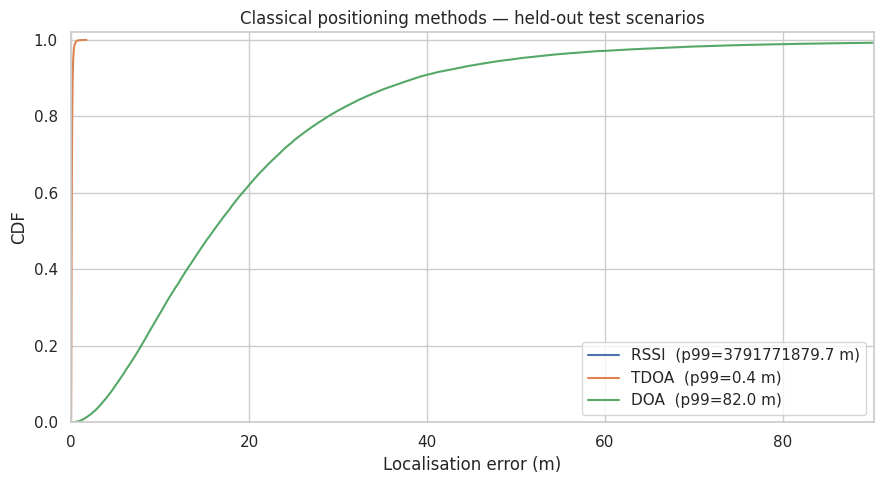

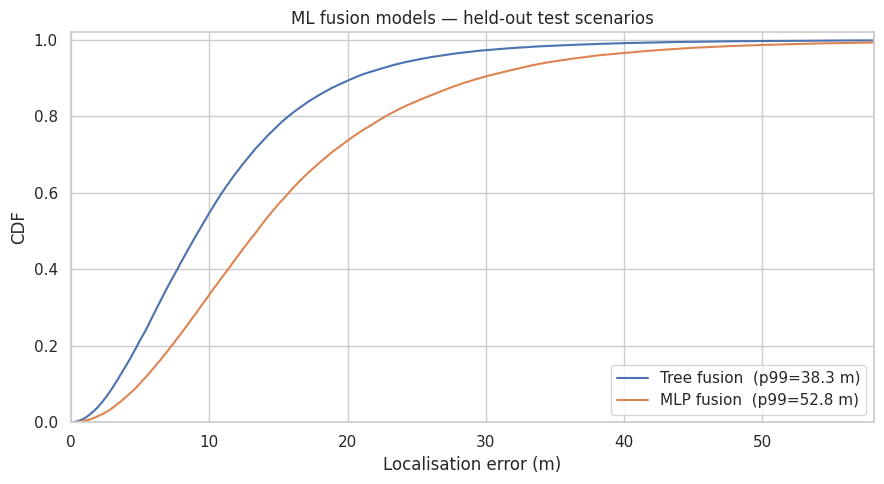

Tree fusion (10.894 m) does not beat TDOA (0.095 m) on this held-out test split. Report that honestly and inspect harder scenarios rather than deepening the network immediately.


In [11]:
# Upload position_estimated.parquet to Colab & update path
POSITION_EST_PATH = DATA_DIR / "position_estimates.parquet"

# Start with the ML models that are always computed in this notebook
final_prediction_map = {
    "Tree fusion": final_test_predictions,
    "MLP fusion": prediction_store.get("MLP fusion"),
}

for key in ["RSSI", "TDOA", "DOA", "Linear fusion"]:
    if key in prediction_store:
        final_prediction_map[key] = prediction_store[key]

missing_baselines = [k for k in ["RSSI", "TDOA", "DOA"] if k not in final_prediction_map]
if missing_baselines:
    if POSITION_EST_PATH is not None and Path(POSITION_EST_PATH).exists():
        pos_est_df = pd.read_parquet(POSITION_EST_PATH)
        print(f"Loaded position estimates from: {POSITION_EST_PATH}  ({len(pos_est_df):,} rows)")

        merged_est = test_eval_df[IDENTIFIER_COLUMNS].merge(
            pos_est_df, on=IDENTIFIER_COLUMNS, how="left"
        )

        for label, (x_col, y_col) in BASELINE_ESTIMATE_MAP.items():
            if label in final_prediction_map:
                continue
            if x_col in merged_est.columns and y_col in merged_est.columns:
                preds = merged_est[[x_col, y_col]].to_numpy(dtype=float)
                finite_rows = np.isfinite(preds).all(axis=1)
                if finite_rows.sum() > 0:
                    n_finite = int(finite_rows.sum())
                    n_total = len(preds)
                    if n_finite < n_total:
                        print(f"Note: {label} has {n_finite:,}/{n_total:,} finite estimate rows ({n_total - n_finite:,} NaN/Inf dropped from metrics).")
                    final_prediction_map[label] = preds
                else:
                    print(f"Warning: {label} estimates are all NaN/Inf after merge — skipping.")
            else:
                print(f"Warning: {x_col}/{y_col} not found in position_estimated.parquet — skipping {label}.")
    else:
        print(
            "position_estimated.parquet not found — classical baseline comparisons will be omitted.\n"
            f"Expected path: {POSITION_EST_PATH}"
        )

# Drop any None entries (shouldn't be any at this point, but just in case) so that the plotting code can assume all values are np.arrays.
final_prediction_map = {k: v for k, v in final_prediction_map.items() if v is not None}

final_test_summary_df = pd.DataFrame(
    [metric_row("test", model_name, y_test, preds) for model_name, preds in final_prediction_map.items()]
).sort_values("mean_error_m")
display(final_test_summary_df)

# Split predictions into two groups for separate plots
CLASSICAL_NAMES = ["RSSI", "TDOA", "DOA"]
ML_NAMES = ["Tree fusion", "MLP fusion", "Linear fusion"]

classical_map = {k: final_prediction_map[k] for k in CLASSICAL_NAMES if k in final_prediction_map}
ml_map = {k: final_prediction_map[k] for k in ML_NAMES if k in final_prediction_map}


def _per_method_p99(pred_dict):
    """Return a dict of {method_name: 99th-percentile error} for each method."""
    result = {}
    for name, p in pred_dict.items():
        errors = localisation_error_m(y_test, p)
        finite = errors[np.isfinite(errors)]
        if len(finite) > 0:
            result[name] = float(np.percentile(finite, 99))
    return result


def _x_max_for(pred_dict, robust=False):
    """
    Compute a sensible x-axis upper limit.
    robust=True  → median of per-method 99th percentiles (prevents one outlier
                   method from dominating the axis scale).
    robust=False → max of per-method 99th percentiles (shows full range).
    Result is multiplied by 1.10 to add a small right margin.
    """
    p99s = list(_per_method_p99(pred_dict).values())
    if not p99s:
        return 100.0
    chosen = float(np.median(p99s)) if robust else float(np.max(p99s))
    return chosen * 1.10


def _plot_cdf(pred_dict, title, x_max):
    p99s = _per_method_p99(pred_dict)
    plt.figure(figsize=(9, 5))
    for model_name, preds in pred_dict.items():
        errors = localisation_error_m(y_test, preds)
        finite_errors = np.sort(errors[np.isfinite(errors)])
        cdf = np.arange(1, len(finite_errors) + 1) / len(finite_errors)
        p99_label = f"  (p99={p99s[model_name]:.1f} m)" if model_name in p99s else ""
        plt.plot(finite_errors, cdf, label=f"{model_name}{p99_label}")
    plt.xlim(left=0, right=x_max)
    plt.ylim(0, 1.02)
    plt.xlabel("Localisation error (m)")
    plt.ylabel("CDF")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Plot 1 — Classical positioning methods
if classical_map:
    classical_x_max = _x_max_for(classical_map, robust=True)
    print(f"Classical plot x-axis cap: {classical_x_max:.1f} m  (median of per-method p99 × 1.1)")
    _plot_cdf(classical_map, "Classical positioning methods — held-out test scenarios", classical_x_max)
else:
    print("No classical baseline predictions available to plot.")

# Plot 2 — ML fusion models
if ml_map:
    _plot_cdf(ml_map, "ML fusion models — held-out test scenarios", _x_max_for(ml_map))
else:
    print("No ML model predictions available to plot.")

tree_rows = final_test_summary_df[final_test_summary_df["model"] == "Tree fusion"]
tdoa_rows = final_test_summary_df[final_test_summary_df["model"] == "TDOA"]

if tree_rows.empty:
    print("Tree fusion results not found in summary.")
else:
    tree_mean = tree_rows["mean_error_m"].iloc[0]
    tdoa_mean = tdoa_rows["mean_error_m"].iloc[0] if not tdoa_rows.empty else float("nan")

    if not np.isfinite(tdoa_mean):
        print(
            f"Tree fusion mean error: {tree_mean:.3f} m\n"
            "Note: TDOA has no finite estimates available for comparison — "
            "check that position_estimated.parquet contains valid tdoa_est_x/tdoa_est_y values."
        )
    elif tree_mean < tdoa_mean:
        print(f"Tree fusion ({tree_mean:.3f} m) beats TDOA ({tdoa_mean:.3f} m) on this held-out test split.")
    else:
        print(
            f"Tree fusion ({tree_mean:.3f} m) does not beat TDOA ({tdoa_mean:.3f} m) on this held-out test split. "
            "Report that honestly and inspect harder scenarios rather than deepening the network immediately."
        )


## 7. Optional: run the repo evaluator

If the repo is available in the Colab runtime, this step will run the existing evaluation script using the exported `ml_predictions.parquet` file.


In [12]:
EVALUATOR_SCRIPT = "/ML Pipeline/evaluate_positioning_performance.py"

if EVALUATOR_SCRIPT is None:
    print("Evaluator script not found in this runtime.")
    print("If needed, clone the repo in Colab or update EVALUATOR_SCRIPT manually.")
else:
    print(f"Running evaluator: {EVALUATOR_SCRIPT}")
    !python "{EVALUATOR_SCRIPT}" --data-dir "{DATA_DIR}" --predictions-path "{PREDICTIONS_PATH}"


Running evaluator: /ML Pipeline/evaluate_positioning_performance.py
Wrote positioning performance outputs:
- method_summary: /ML Pipeline/evaluation/method_performance_summary.csv
- condition_summary: /ML Pipeline/evaluation/condition_performance_summary.csv
- error_distribution: /ML Pipeline/evaluation/method_error_distribution.png
- error_cdf: /ML Pipeline/evaluation/method_error_cdf.png
- ml_improvement: /ML Pipeline/evaluation/ml_vs_baseline_improvement.csv
- paired_comparisons: /ML Pipeline/evaluation/paired_method_comparisons.csv
